# Question 4: Do age cohorts differ in life satisfaction and trust? 

Life satisfaction is the ESS core item ***stflife***, measured from 0 to 10, where 0 means extremely dissatisfied and 10 means extremely satisfied. This item is asked in every round and is a standard indicator of subjective well‑being. Furthermore, Institutional trust can be summarised by a simple index that average trust in parliament ***(trstprl)*** on a 0 to 10 scale. These are long‑standing ESS items designed to capture political and institutional trust.

In [3]:
# Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

## Cohort gaps in life satisfaction

*Across the ESS rounds, which birth cohorts have the highest and lowest average life satisfaction?*

<positron-console-cell-4>:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


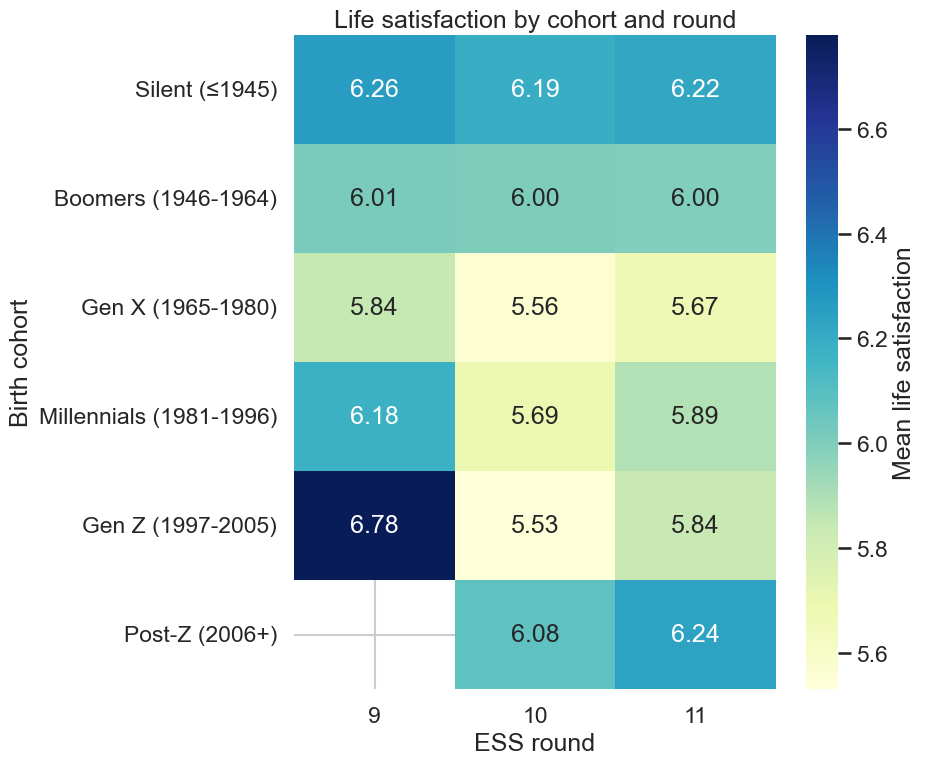

In [4]:
# Cohort gaps in life satisfaction

df = pd.read_csv("ess_final_analysis.csv")

df["stflife"]  = pd.to_numeric(df["stflife"],  errors="coerce")
df["anweight"] = pd.to_numeric(df["anweight"], errors="coerce")
df["essround"] = pd.to_numeric(df["essround"], errors="coerce").round().astype("Int64")

df["stflife"] = df["stflife"].mask(df["stflife"].isin([77, 88, 99]))
df = df.dropna(subset=["anweight", "stflife"])

bins   = [1900, 1945, 1964, 1980, 1996, 2005, 2100]
labels = ["Silent (≤1945)", "Boomers (1946-1964)", "Gen X (1965-1980)",
          "Millennials (1981-1996)", "Gen Z (1997-2005)", "Post-Z (2006+)"]

df["yrbrn"]  = pd.to_numeric(df["yrbrn"], errors="coerce")
df["cohort"] = pd.cut(df["yrbrn"], bins=bins, labels=labels, right=True)
df["cohort"] = pd.Categorical(df["cohort"], categories=labels, ordered=True)

def wmean(g):
    x = g["stflife"].to_numpy(float)
    w = g["anweight"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

agg = (df.groupby(["cohort", "essround"], observed=True)
        .apply(wmean).rename("stflife_mean").reset_index())

round_order = sorted(agg["essround"].dropna().unique())
heat = (agg.pivot(index="cohort", columns="essround", values="stflife_mean")
           .reindex(index=labels, columns=round_order))

sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(1.8*len(round_order)+4, 1.0*len(labels)+2))
ax = sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu",
                 cbar_kws={"label": "Mean life satisfaction"})
ax.set(xlabel="ESS round", ylabel="Birth cohort",
       title="Life satisfaction by cohort and round")
plt.tight_layout()
plt.show()

Gen Z is highest in Round 9 (6.78), while Gen X is lowest (5.84). Across cohorts, Round 10 shows a clear dip (for example Gen Z 5.53, Gen X 5.56), followed by a partial rise in Round 11 (for example Gen Z 5.84, Millennials 5.89). Post‑Z appears only in Rounds 10 and 11 (6.08 and 6.24), because it is not present in Round 9. This pattern is consistent with the idea that cohorts can display persistent differences because orientations formed in formative years tend to be relatively stable, which helps explain why the cohort ordering does not completely reverse across rounds (Welzel et al., 2024; O’Grady, 2023).  The across‑the‑board decline in Round 10 aligns with research showing that the COVID‑19 period acted as a major collective disruption that produced short‑run shifts in attitudes and evaluations, even when deeper orientations remain comparatively stable (Welzel et al., 2024; Bonetto et al., 2021).  

Evidence from the pandemic literature also shows that heightened threat and uncertainty can shift psychological priorities toward security‑related concerns and away from openness, which provides a plausible mechanism for the broad downturn seen in Round 10 (Bonetto et al., 2021; Vecchione, 2022).  The partial recovery by Round 11 fits the expectation that some changes observed during crises reflect period conditions rather than a permanent re‑structuring of generational differences, so wellbeing can rebound as the external shock weakens (O’Grady, 2023; Welzel et al., 2024). Overall, the figure supports a mixed account: cohort differences are visible, but the pandemic period coincides with a general downward shift in life satisfaction in Round 10, followed by partial recovery in Round 11. This combination is consistent with research that treats crises as producing short‑term period effects layered on top of more durable cohort patterning (Welzel et al., 2024; O’Grady, 2023).

## Cohort gaps in institutional trust
*Across the ESS rounds, which birth cohorts have the highest and lowest average institutional trust?*



<positron-console-cell-5>:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


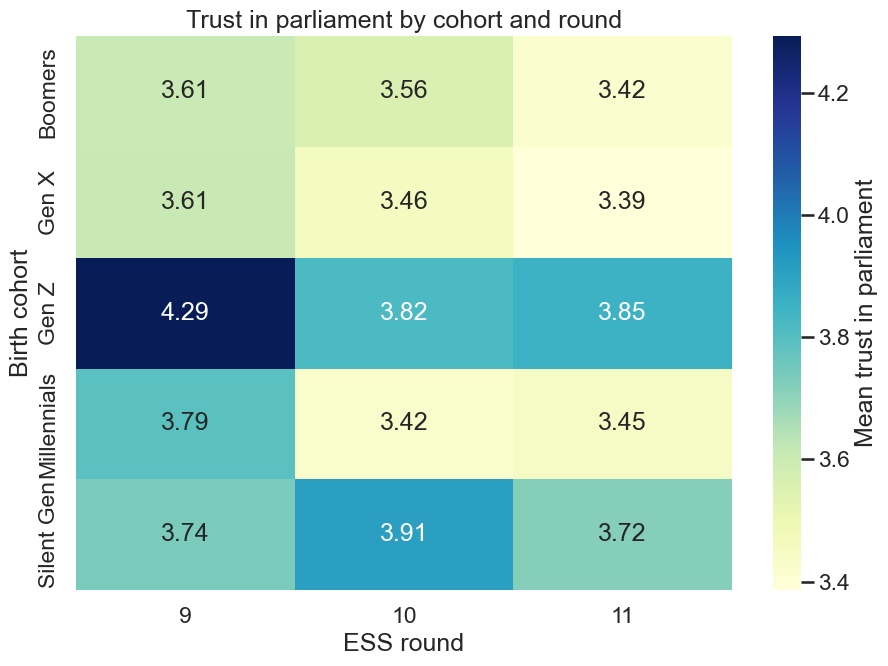

In [5]:
df = pd.read_csv("ess_final_analysis.csv")
df.columns = df.columns.str.strip()

# Only trust variable available
df["trstprl"] = pd.to_numeric(df["trstprl"], errors="coerce").mask(lambda s: s.isin([77,88,99]))

df["anweight"] = pd.to_numeric(df["anweight"], errors="coerce")
df["essround"] = pd.to_numeric(df["essround"], errors="coerce").round().astype("Int64")
df = df.dropna(subset=["anweight"])

# Use existing generation label if you want (recommended since you already have it)
if "generation" in df.columns:
    df["cohort"] = pd.Categorical(df["generation"], ordered=True)
    cohort_order = sorted(df["cohort"].dropna().unique())
else:
    bins   = [1900, 1945, 1964, 1980, 1996, 2005, 2100]
    labels = ["Silent (≤1945)", "Boomers (1946-1964)", "Gen X (1965-1980)",
              "Millennials (1981-1996)", "Gen Z (1997-2005)", "Post-Z (2006+)"]
    df["yrbrn"]  = pd.to_numeric(df["yrbrn"], errors="coerce")
    df["cohort"] = pd.cut(df["yrbrn"], bins=bins, labels=labels, right=True)
    df["cohort"] = pd.Categorical(df["cohort"], categories=labels, ordered=True)
    cohort_order = labels

def wmean(g):
    x = g["trstprl"].to_numpy(float)
    w = g["anweight"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

agg = (df.dropna(subset=["cohort", "trstprl"])
         .groupby(["cohort", "essround"], observed=True)
         .apply(wmean).rename("trust_parliament_mean").reset_index())

round_order = sorted(agg["essround"].dropna().unique())
heat = (agg.pivot(index="cohort", columns="essround", values="trust_parliament_mean")
          .reindex(index=cohort_order, columns=round_order))

sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(1.8*len(round_order)+4, 1.0*len(cohort_order)+2))
ax = sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu",
                 cbar_kws={"label": "Mean trust in parliament"})
ax.set(xlabel="ESS round", ylabel="Birth cohort",
       title="Trust in parliament by cohort and round")
plt.tight_layout()
plt.show()

The colour gradient and cell values indicate average trust levels for each cohort over time. In Round 9, Gen Z shows the highest trust (4.29), while Boomers and Gen X report lower levels (3.61 each). In Round 10, trust declines for most cohorts, with values clustering between 3.42 and 3.91. By Round 11, trust remains lower than in Round 9 for most cohorts, with Gen Z at 3.85 and Gen X at 3.39, while the Silent cohort shows relatively higher stability (3.72). The higher trust levels among younger cohorts in Round 9 are consistent with research showing that generational differences in political attitudes reflect distinct formative experiences and institutional evaluations acquired early in life (Welzel et al., 2024; O’Grady, 2023). Younger cohorts often attach different meanings to political institutions compared to older cohorts, which can result in systematically higher or lower trust depending on context (Lauterbach & De Vries, 2021). The broad decline in trust from Round 9 to Round 10 across cohorts aligns with evidence that the COVID‑19 pandemic disrupted political trust, particularly when government responses were contested or communication was inconsistent (Seyd & Bu, 2022; Stivas & Cole, 2023). 

Studies show that trust in political institutions became more volatile during the pandemic, as uncertainty and perceived risk altered evaluations of government performance (Bonetto et al., 2021; Algan et al., 2021). The partial stabilisation but incomplete recovery in Round 11 is consistent with findings that political trust does not automatically rebound after crises and may remain depressed even as immediate threats recede, especially when citizens reassess institutional competence and transparency (Seyd & Bu, 2022; Stivas & Cole, 2023). Differences across cohorts suggest that pandemic‑era trust shifts interacted with life stage and prior institutional expectations rather than producing uniform attitudinal change (Vecchione, 2022). Overall, the figure supports an interpretation in which cohort differences in trust in parliament persist, but are overlaid by a strong negative period effect during the pandemic. Trust declines sharply in Round 10 and does not fully recover by Round 11, indicating that COVID‑19 coincided with a durable weakening of institutional trust. This pattern is consistent with research showing that crises can generate lasting reassessments of political institutions while still preserving underlying generational structuring of attitudes (Welzel et al., 2024; O’Grady, 2023).

## Distributional view
*How do the distributions of life satisfaction differ across cohorts and which cohorts appear most or least dispersed?*

<positron-console-cell-6>:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


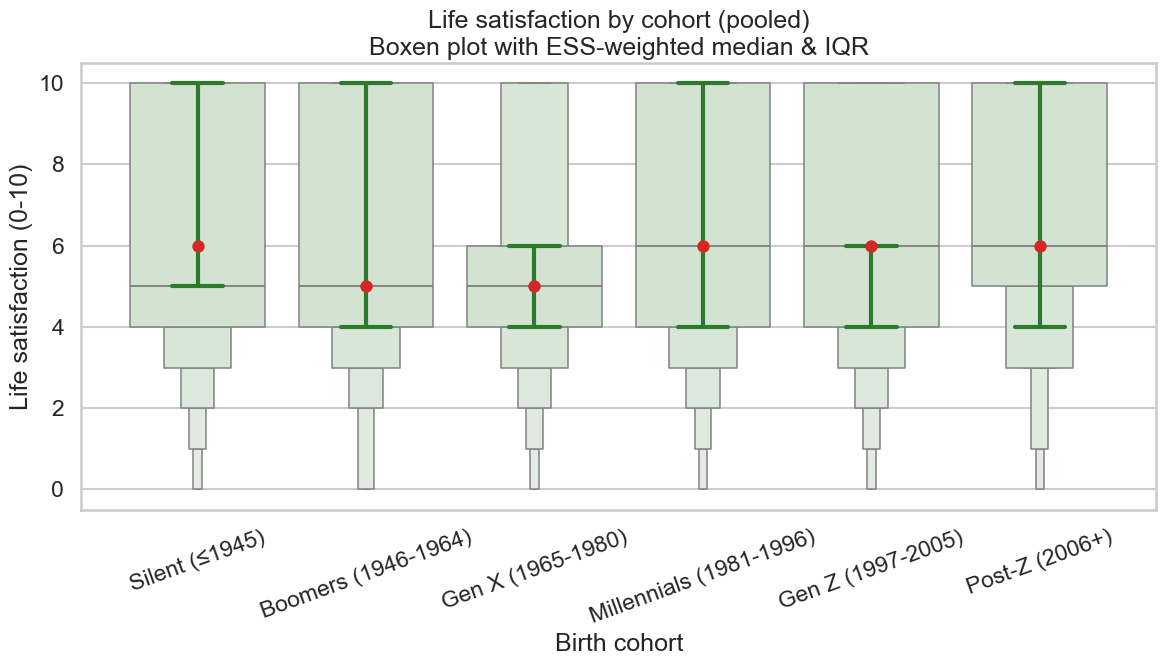

In [6]:
# Distributional view

df = pd.read_csv("ess_final_analysis.csv")
df["stflife"]  = pd.to_numeric(df["stflife"],  errors="coerce").mask(lambda s: s.isin([77,88,99]))
df["anweight"] = pd.to_numeric(df["anweight"], errors="coerce")
df["yrbrn"]    = pd.to_numeric(df["yrbrn"],    errors="coerce")
df = df.dropna(subset=["anweight", "stflife"])

bins   = [1900, 1945, 1964, 1980, 1996, 2005, 2100]
labels = ["Silent (≤1945)", "Boomers (1946-1964)", "Gen X (1965-1980)",
          "Millennials (1981-1996)", "Gen Z (1997-2005)", "Post-Z (2006+)"]
df["cohort"] = pd.cut(df["yrbrn"], bins=bins, labels=labels, right=True)
df = df.dropna(subset=["cohort"])
df["cohort"] = pd.Categorical(df["cohort"], categories=labels, ordered=True)

def wq(x, w, qs):
    x, w = np.asarray(x, float), np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not m.any(): return np.full(len(np.atleast_1d(qs)), np.nan)
    x, w = x[m], w[m]
    idx = np.argsort(x); x, w = x[idx], w[idx]
    cw = w.cumsum(); cw /= cw[-1]
    return np.interp(np.atleast_1d(qs), cw, x)

stats = (df.groupby("cohort", observed=True)
           .apply(lambda g: pd.Series(dict(q25=wq(g["stflife"], g["anweight"], .25),
                                           q50=wq(g["stflife"], g["anweight"], .50),
                                           q75=wq(g["stflife"], g["anweight"], .75))))
           .reindex(labels))

sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxenplot(data=df, x="cohort", y="stflife",
              order=labels, color="#cfe6cf", k_depth="proportion", ax=ax)

for i, coh in enumerate(labels):
    row = stats.loc[coh]
    if pd.notna(row["q50"]):
        ax.scatter(i, row["q50"], color="#d62728", s=55, zorder=3)
        ax.vlines(i, row["q25"], row["q75"], color="#2c7a2c", lw=3)
        ax.plot([i-0.15, i+0.15], [row["q25"], row["q25"]], color="#2c7a2c", lw=3)
        ax.plot([i-0.15, i+0.15], [row["q75"], row["q75"]], color="#2c7a2c", lw=3)

ax.set(xlabel="Birth cohort", ylabel="Life satisfaction (0-10)",
       title="Life satisfaction by cohort (pooled)\nBoxen plot with ESS-weighted median & IQR")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The red dots mark the ESS‑weighted median life satisfaction for each cohort, and these medians are approximately 6 for Silent, 6 for Millennials, 6 for Gen Z, and 6 for Post‑Z, while Boomers and Gen X have lower medians around 5. The green vertical lines show the ESS‑weighted interquartile range (IQR), and the figure indicates wider IQRs for Silent and Post‑Z and a narrower IQR for Gen X. The tails in the boxen layers extend toward both ends of the scale, indicating that some respondents in every cohort report very low scores (near 0–2) and some report very high scores (near 9–10), even when the cohort medians differ. The plot shows that cohort differences are not only about averages; there is also meaningful within‑cohort variation. This fits the idea that people’s orientations form during formative years and then stabilise, but populations still display heterogeneity because individuals experience different social and economic conditions even within the same cohort (Welzel et al., 2024). The visible spread in each cohort is consistent with evidence that disruptive contexts can interact with personal circumstances, producing different psychological and evaluative outcomes across individuals rather than uniform shifts (Vecchione, 2022).  

COVID‑19 research also shows that crises can create heterogeneous responses across people, especially when threat perceptions and material conditions differ, which helps explain why distributions remain wide even when medians are similar across cohorts (Bonetto et al., 2021; Vecchione, 2022). The boxen shape also implies that some cohorts have heavier tails, which is compatible with findings that pandemic‑era experiences and constraints varied across subgroups and could widen dispersion in wellbeing‑related evaluations (Bojanowska et al., 2021). Overall, the figure indicates that cohort medians differ, but the key message is that dispersion within cohorts is substantial, meaning cohort averages alone can hide important inequality in lived experience. This pattern supports a cohort‑and‑context perspective in which generational structuring matters, yet individual circumstances and shock exposure generate meaningful variation inside each generation (Welzel et al., 2024; Vecchione, 2022).